In [1]:
import SRC
import os
import sys
from SRC.helpFolder import *

metadata = SRC.load_model_metadata()

In [2]:
metadata['weatherInformation']['weather_end_date'], metadata['PMSInformation']['end_date_range']

('2025-06-07', '2025-08-30')

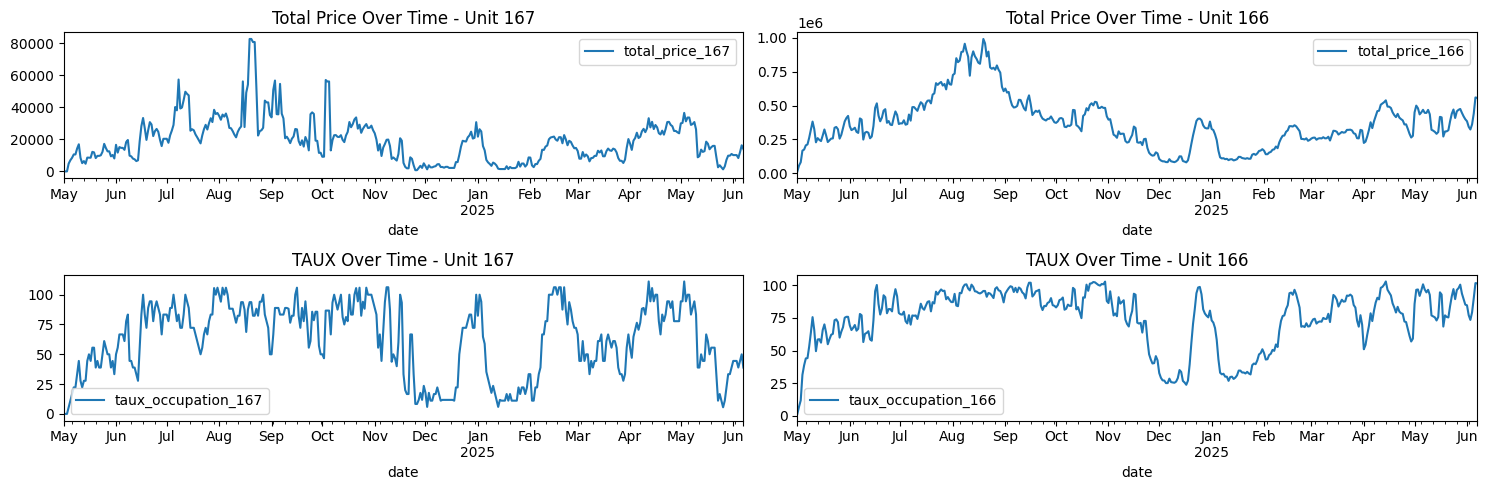

In [3]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['weatherInformation']['weather_end_date']
)

In [4]:
df_weather = make_weather_data_dataframe(weather_data_path = f"../{metadata['weatherInformation']['archive_json_path']}")

In [11]:
def concatenate_on_index(df1, df2):
    """
    Concatenate two DataFrames along the columns (axis=1), aligning them by index.

    Parameters:
    df1 (pd.DataFrame): The first DataFrame.
    df2 (pd.DataFrame): The second DataFrame.
    """
    return pd.concat([df1, df2], axis=1)

In [6]:
df_166_weather = concatenate_on_index(df_166, df_weather)
df_167_weather = concatenate_on_index(df_167, df_weather)

In [8]:
df_166_weather.head(3)

,dayofweek,month,year,dayofyear,weekofyear,total_price_166,taux_occupation_166,temperature_max,temperature_min,temperature_mean,precipitation,windspeed_max,temperature_range
date,,,,,,,,,,,,,
2024-05-01,2,5,2024,122,18,14048.16,1.45,26.326,10.676,17.949,0.0,13.556,15.65
2024-05-02,3,5,2024,123,18,57342.62,7.00,27.276,11.126,19.288,0.0,13.398,16.15
2024-05-03,4,5,2024,124,18,81992.10,11.84,31.876,10.726,21.576,0.0,11.542,21.15


In [10]:
df_167_weather.head(3)

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167,temperature_max,temperature_min,temperature_mean,precipitation,windspeed_max,temperature_range
date,,,,,,,,,,,,,
2024-05-01,2,5,2024,122,18,0.0,0.0,26.326,10.676,17.949,0.0,13.556,15.65
2024-05-02,3,5,2024,123,18,0.0,0.0,27.276,11.126,19.288,0.0,13.398,16.15
2024-05-03,4,5,2024,124,18,0.0,0.0,31.876,10.726,21.576,0.0,11.542,21.15


--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: price (predicting price)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Model Evaluation Metrics:
Train RMSE: 92994.81
Test RMSE: 91979.60
Train MAE: 69371.81
Test MAE: 76180.75
Train R²: 0.7976
Test R²: -0.2264

Feature Importance (Coefficients):
                Feature   Coefficient
2                  year  517

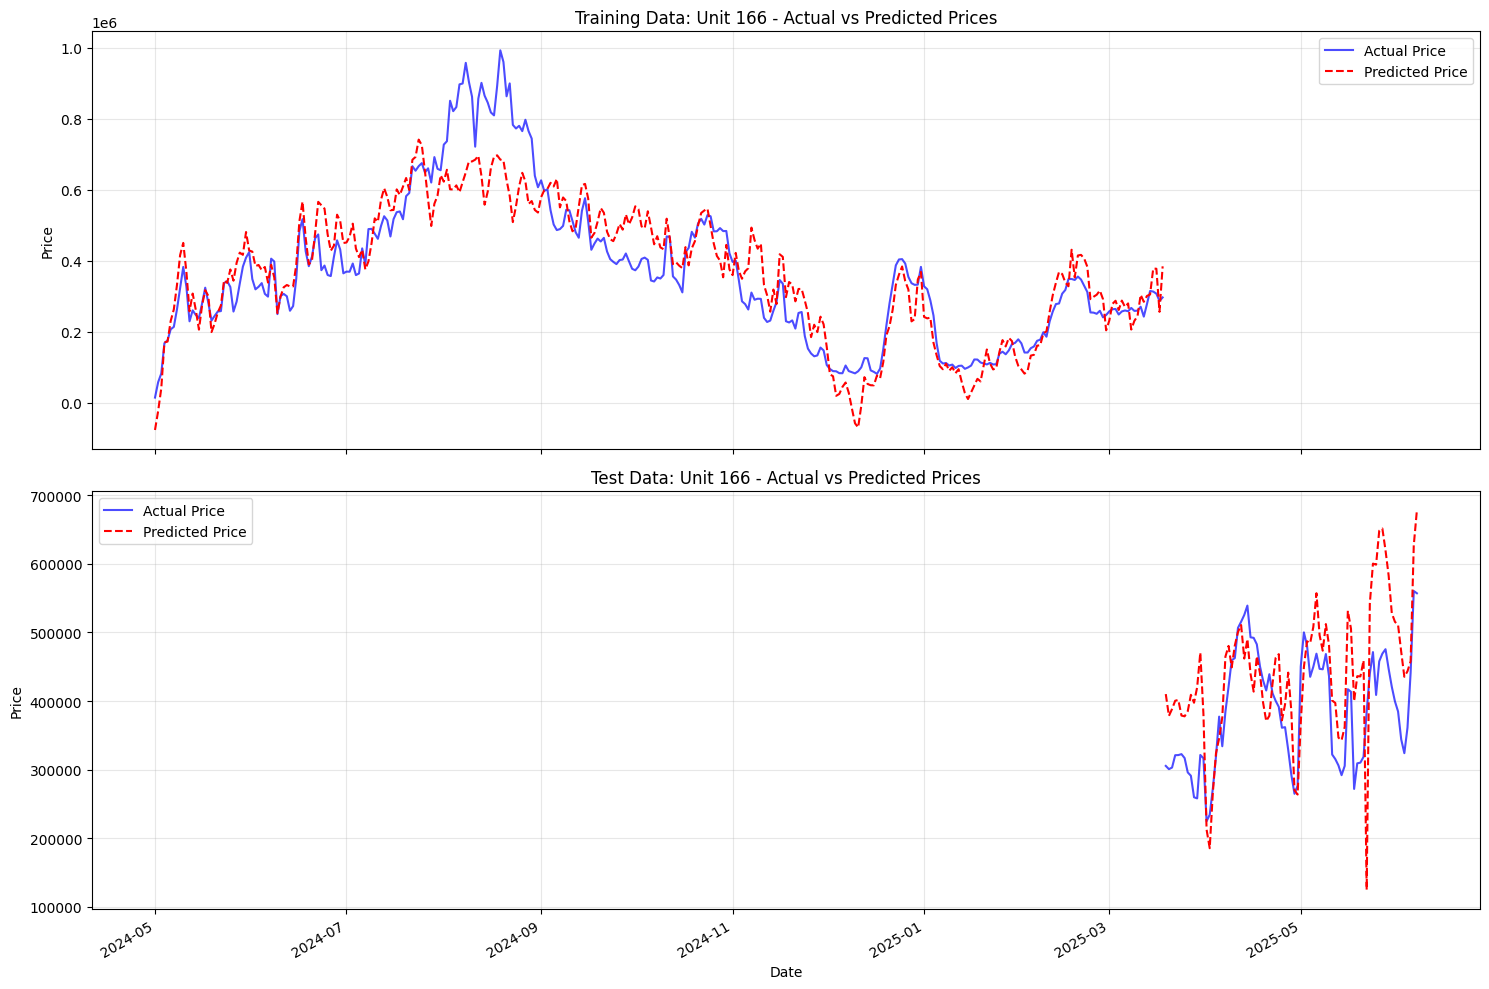

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_166


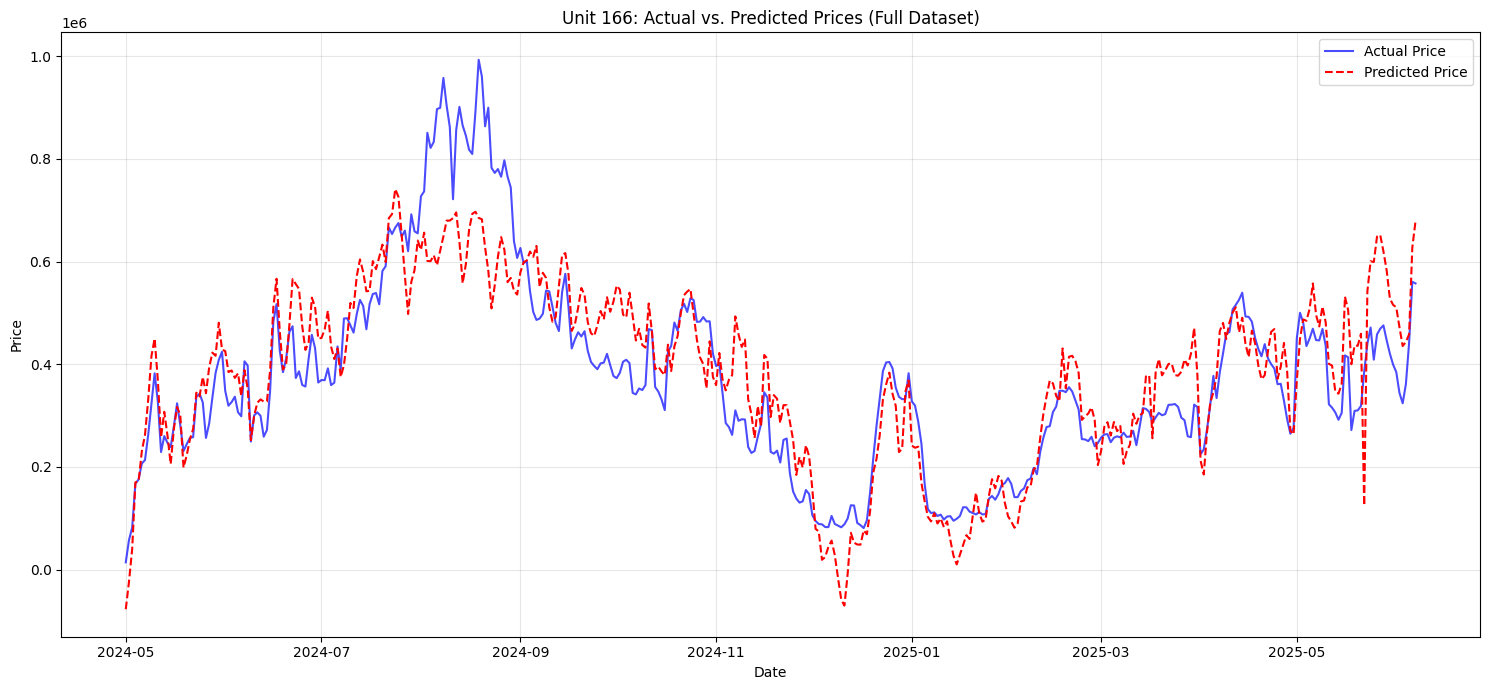


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---


In [12]:
result_166 = run_linear_regression_pipeline(
    df_unit=df_166_weather,
    unit_id='166',
    test_size=0.2,
    target_type='price'
)

In [ ]:
def predict_single_date_linear_model(model, target_date_str, unit_id, value_target, target_type='price', city=metaData['weatherInformation']['default_city']):
    """
    Predicts either price or occupancy rate for a single future date using a trained linear regression model,
    including weather features for the specified date and city.

    Args:
        model: The trained scikit-learn compatible linear regression model.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        value_target (float): The value for the non-target feature (price or taux_occupation).
        target_type (str): Type of prediction ('price' or 'taux'). Defaults to 'price'.
        city (str): City name for weather data. Defaults to 'Paris'.
    """
    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        print(f"Error: Invalid target_date_str format: {target_date_str}. Please use 'YYYY-MM-DD'.")
        return None

    if target_type.lower() == 'price':
        feature_name = f'taux_occupation_{unit_id}'
        target_name = f'total_price_{unit_id}'
    else:  
        feature_name = f'total_price_{unit_id}'
        target_name = f'taux_occupation_{unit_id}'

    features = {
        'dayofweek': target_date.dayofweek,
        'month': target_date.month,
        'year': target_date.year,
        'dayofyear': target_date.dayofyear,
        'weekofyear': int(target_date.isocalendar()[1]),
        feature_name: value_target
    }

    try:
        
        weather_df = get_weather_dataframe_for_city_single_date(target_date_str, city)
        
        if not weather_df.empty:

            weather_row = weather_df.iloc[0]  
            
            features.update({
                'temperature_max': weather_row['temperature_max'],
                'temperature_min': weather_row['temperature_min'],
                'temperature_mean': weather_row['temperature_mean'],
                'precipitation': weather_row['precipitation'],
                'windspeed_max': weather_row['windspeed_max'],
                'temperature_range': weather_row['temperature_range']
            })
            
            print(f"Weather data successfully retrieved for {city} on {target_date_str}")
        else:
            print(f"Warning: No weather data available for {city} on {target_date_str}. Using default values.")

            features.update({
                'temperature_max': 0.0,
                'temperature_min': 0.0,
                'temperature_mean': 0.0,
                'precipitation': 0.0,
                'windspeed_max': 0.0,
                'temperature_range': 0.0
            })
            
    except Exception as e:
        print(f"Error retrieving weather data: {e}")
        print("Using default weather values.")
        features.update({
            'temperature_max': 0.0,
            'temperature_min': 0.0,
            'temperature_mean': 0.0,
            'precipitation': 0.0,
            'windspeed_max': 0.0,
            'temperature_range': 0.0
        })

    if hasattr(model, 'feature_names_in_'):
        feature_order = list(model.feature_names_in_)
    else:
        feature_order = [
            'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 
            feature_name,
            'temperature_max', 'temperature_min', 'temperature_mean', 
            'precipitation', 'windspeed_max', 'temperature_range'
        ]
        print(f"Warning: Model does not have 'feature_names_in_'. Using default feature order: {feature_order}")
    
    try:
        model_features = {col: features.get(col, 0.0) for col in feature_order}
        input_df = pd.DataFrame([model_features], columns=feature_order)
    except Exception as e:
        print(f"Error creating DataFrame for prediction: {e}")
        return None
        
    for col in feature_order:
        if col not in input_df.columns:
            print(f"Error: Missing expected feature '{col}' in the generated input.")
            return None
            
    print(f"\nPredicting {target_name} for Unit {unit_id} on {target_date_str} with features:")

    try:
        prediction = model.predict(input_df)
        return prediction[0]  
    except Exception as e:
        print(f"Error during prediction: {e}")
        
        if hasattr(model, 'feature_names_in_'):
            print(f"Model was trained with features: {model.feature_names_in_}")
        print(f"Input features provided: {input_df.columns.tolist()}")
        
        return None

In [ ]:
prediction = predict_single_date_linear_model(
    model=result_166['model'],
    target_date_str='2024-07-10',
    unit_id='166',
    value_target=100.0, 
    target_type='price',
)

Found coordinates for Marrakech: 31.6258, -7.9892
Fetching historical data only
Coordinates 31.59929656982422°N -7.97607421875°E
Elevation 468.0 m asl
Timezone NoneNone
Successfully fetched weather data for 1 dates
Successfully created DataFrame for Marrakech on 2024-07-10
Weather data successfully retrieved for Marrakech on 2024-07-10

Predicting total_price_166 for Unit 166 on 2024-07-10 with features:


In [15]:
prediction

635970.0500917882